In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# load the dataset
df = pd.read_csv(r'D:\Eda_project\loan_data_clean.csv')
print("Datasest loaded successfully")
print("shape:",df.shape)

Datasest loaded successfully
shape: (5000, 31)


In [4]:
df.head

<bound method NDFrame.head of      customer_id          full_name  age  gender marital_status       city  \
0      CUST10001    Aishwarya Desai   39  Female        Married     Mumbai   
1      CUST10002         Neha Verma   29    Male        Married    Kolkata   
2      CUST10003       Arjun Pandey   28  Female         Single  Hyderabad   
3      CUST10004       Ganesh Singh   29  Female        Married     Mumbai   
4      CUST10005       Rahul Pandey   36    Male         Single    Lucknow   
...          ...                ...  ...     ...            ...        ...   
4995   CUST14996     Vijay Malhotra   38    Male        Married  Ahmedabad   
4996   CUST14997  Suresh Srivastava   35    Male        Married  Ahmedabad   
4997   CUST14998      Varsha Bansal   30  Female        Married      Delhi   
4998   CUST14999      Rashmi Jadhav   37  Female        Married      Surat   
4999   CUST15000       Madhuri Nair   35    Male         Single  Bangalore   

              state      educatio

In [5]:
# checking quality of data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            5000 non-null   str    
 1   full_name              5000 non-null   str    
 2   age                    5000 non-null   int64  
 3   gender                 5000 non-null   str    
 4   marital_status         5000 non-null   str    
 5   city                   5000 non-null   str    
 6   state                  5000 non-null   str    
 7   education              5000 non-null   str    
 8   employment_type        5000 non-null   str    
 9   years_of_experience    5000 non-null   int64  
 10  monthly_income         5000 non-null   int64  
 11  loan_id                5000 non-null   str    
 12  loan_type              5000 non-null   str    
 13  loan_amount            5000 non-null   int64  
 14  loan_tenure_months     5000 non-null   int64  
 15  interest_rate  

In [6]:
# check missing values
df.isnull().sum()

customer_id                 0
full_name                   0
age                         0
gender                      0
marital_status              0
city                        0
state                       0
education                   0
employment_type             0
years_of_experience         0
monthly_income              0
loan_id                     0
loan_type                   0
loan_amount                 0
loan_tenure_months          0
interest_rate               0
emi_amount                  0
loan_purpose                0
loan_application_date       0
loan_approval_status        0
credit_score                0
existing_loans              0
total_existing_debt         0
debt_to_income_ratio        0
collateral_value          633
co_applicant              677
repayment_status          207
missed_payments           207
default_status            207
days_past_due             207
recovery_amount          4079
dtype: int64

In [7]:
# handling missing values
df['collateral_value'] = df['collateral_value'].fillna(df['collateral_value'].median())
df['missed_payments'] = df['missed_payments'].fillna(0)
df['default_status'] = df['default_status'].fillna(2)
df['days_past_due'] = df['days_past_due'].fillna(0)
df['recovery_amount'] = df['recovery_amount'].fillna(0)

print(df.isnull().sum())

customer_id                0
full_name                  0
age                        0
gender                     0
marital_status             0
city                       0
state                      0
education                  0
employment_type            0
years_of_experience        0
monthly_income             0
loan_id                    0
loan_type                  0
loan_amount                0
loan_tenure_months         0
interest_rate              0
emi_amount                 0
loan_purpose               0
loan_application_date      0
loan_approval_status       0
credit_score               0
existing_loans             0
total_existing_debt        0
debt_to_income_ratio       0
collateral_value           0
co_applicant             677
repayment_status         207
missed_payments            0
default_status             0
days_past_due              0
recovery_amount            0
dtype: int64


In [8]:
df.describe()

,age,years_of_experience,monthly_income,loan_amount,loan_tenure_months,interest_rate,emi_amount,credit_score,existing_loans,total_existing_debt,debt_to_income_ratio,collateral_value,missed_payments,default_status,days_past_due,recovery_amount
count,5000.000000,5000.00000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.00000,5000.00000,5000.000000,5.000000e+03
mean,34.624800,13.23060,163359.357600,1.965891e+06,86.140800,13.037058,42177.043600,681.379600,1.197400,54253.023200,0.886364,2.106060e+06,1.84260,0.30540,93.755800,1.374354e+05
std,8.487027,8.48744,94364.345301,1.932048e+06,75.126529,3.184242,39497.319414,79.231354,1.165807,63726.177921,1.101776,2.121383e+06,3.42055,0.54313,189.764648,4.538887e+05
min,21.000000,0.00000,20027.000000,5.000000e+04,12.000000,7.500000,1221.000000,362.000000,0.000000,0.000000,0.010000,4.284200e+04,0.00000,0.00000,0.000000,0.000000e+00
25%,28.000000,7.00000,90508.250000,5.600000e+05,36.000000,10.260000,15266.750000,628.000000,0.000000,0.000000,0.250000,6.889178e+05,0.00000,0.00000,0.000000,0.000000e+00
50%,34.000000,13.00000,153542.000000,1.184500e+06,60.000000,13.030000,27632.500000,681.000000,1.000000,38314.500000,0.530000,1.295193e+06,0.00000,0.00000,0.000000,0.000000e+00
75%,40.000000,19.00000,217303.000000,3.024250e+06,120.000000,15.840000,58433.000000,738.000000,2.000000,76426.000000,1.060000,2.727732e+06,2.00000,1.00000,42.000000,0.000000e+00
max,58.000000,35.00000,499954.000000,7.984000e+06,300.000000,18.500000,247039.000000,900.000000,4.000000,319424.000000,14.130000,1.156615e+07,12.00000,2.00000,720.000000,4.164617e+06


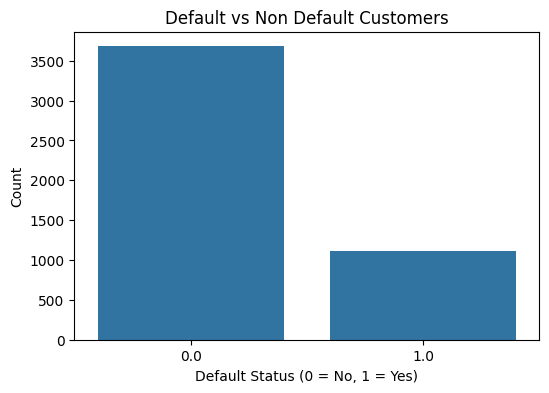

In [9]:
# chart 1 - default vs non default
plt.figure(figsize=(6,4))
sns.countplot(x='default_status',data=df[df['default_status'] != 2])
plt.title('Default vs Non Default Customers')
plt.xlabel('Default Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

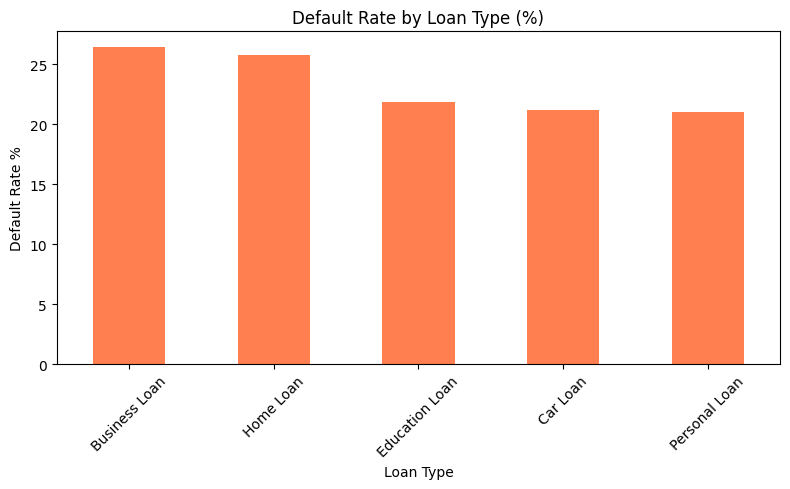

In [10]:
# chart 2 - Default rate by loan  type
loan_default = df[df['default_status'] != 2]
loan_default = loan_default.groupby('loan_type')['default_status'].mean() * 100

plt.figure(figsize=(8,5))
loan_default.sort_values(ascending=False).plot(kind='bar',color= 'coral')
plt.title('Default Rate by Loan Type (%)')
plt.xlabel('Loan Type')
plt.ylabel('Default Rate %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


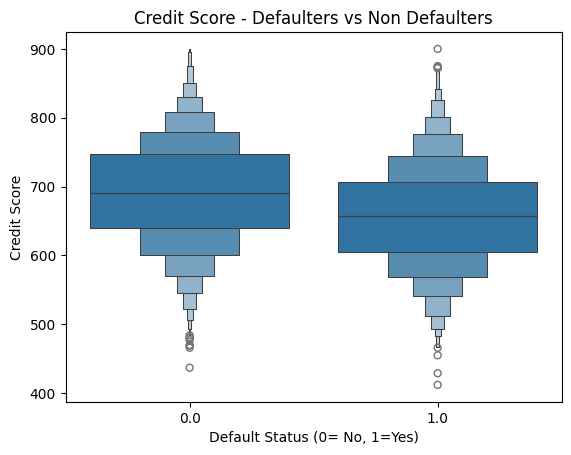

In [11]:
# chart 3 - Credit Score Distribution of Defaulters vs Non Defaulters
approved = df[df['default_status'] != 2]

plt.Figure(figsize=(7,5))
sns.boxenplot(x='default_status', y='credit_score',data=approved)
plt.title('Credit Score - Defaulters vs Non Defaulters')
plt.xlabel('Default Status (0= No, 1=Yes)')
plt.ylabel('Credit Score')
plt.show()

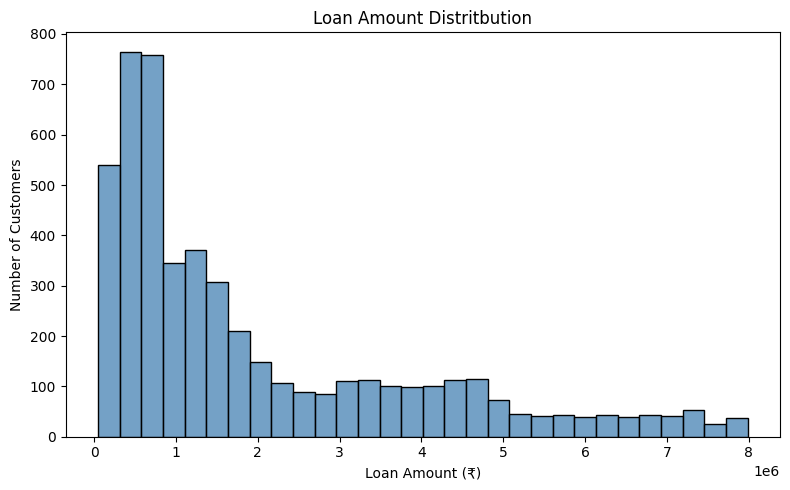

In [12]:
#chart 4 - Loan Amount distribution
plt.figure(figsize=(8,5))
sns.histplot(df['loan_amount'], bins=30,color='steelblue')
plt.title('Loan Amount Distritbution')
plt.xlabel('Loan Amount (₹)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


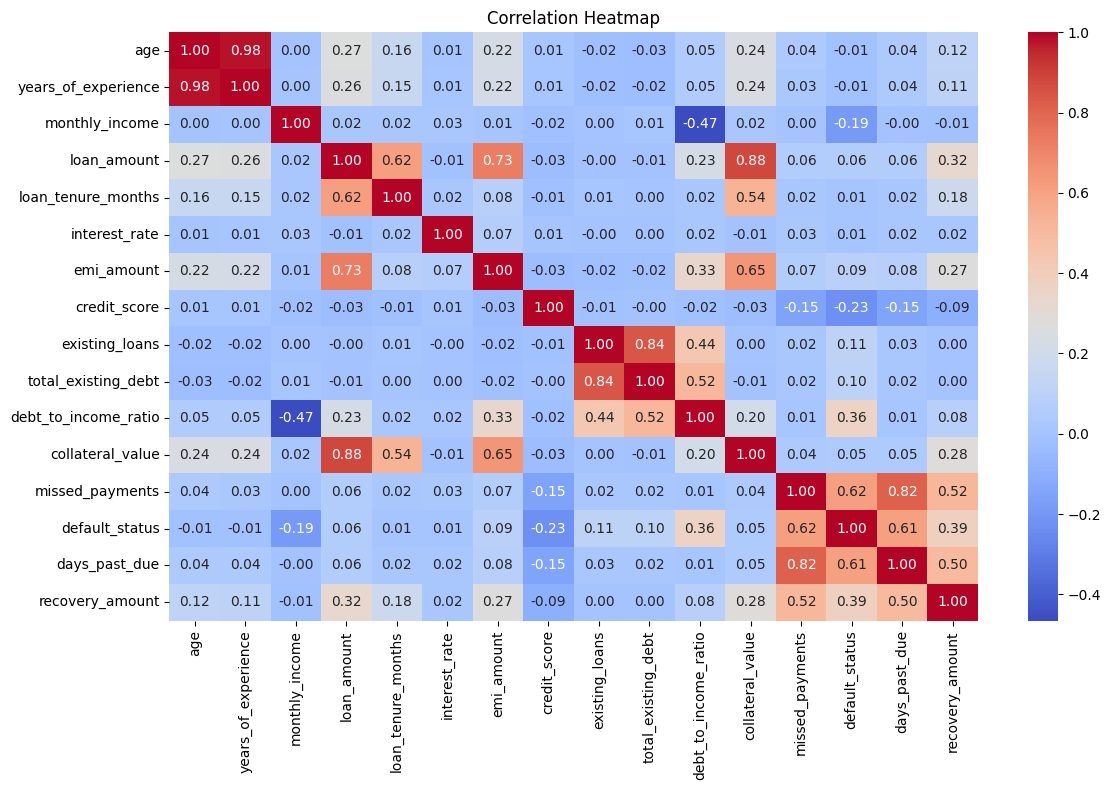

In [13]:
# chart 5 - Correlation Heatmap
plt.figure(figsize=(12,8))
numeric_cols = df.select_dtypes(include='number')
correlation = numeric_cols.corr()
sns.heatmap(correlation,annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [14]:
# importing ml libraries
# Import ML libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

print("ML libraries loaded!")

ML libraries loaded!


In [15]:
# remove rejected loans
ml_df = df[df['default_status'] != 2].copy()

features = ['age', 'monthly_income', 'loan_amount', 
            'loan_tenure_months', 'interest_rate', 
            'credit_score', 'existing_loans', 
            'total_existing_debt', 'debt_to_income_ratio',
            'employment_type', 'loan_type', 'education']

x = ml_df[features]
y = ml_df['default_status']

print('x shape :', x.shape)
print('y shape :', y.shape)

x shape : (4793, 12)
y shape : (4793,)


In [16]:
# convert text to numbers
le = LabelEncoder()

x = x.copy()
x['employment_type'] = le.fit_transform(x['employment_type'])
x['loan_type'] = le.fit_transform(x['loan_type'])
x['education'] = le.fit_transform(x['education'])

print("text columns converted")
print(x.head())

text columns converted
   age  monthly_income  loan_amount  loan_tenure_months  interest_rate  \
1   29           90526      1601000                 120          15.21   
2   28           35451       294000                  84           8.56   
4   36          283059      1098000                  36          13.38   
5   25          147106       380000                  48          10.45   
6   28          235955       279000                  24          13.10   

   credit_score  existing_loans  total_existing_debt  debt_to_income_ratio  \
1           637               0                    0                  0.29   
2           508               0                    0                  0.13   
4           523               1                70589                  0.38   
5           553               2               102490                  0.76   
6           728               1                16175                  0.12   

   employment_type  loan_type  education  
1                1  

In [17]:
# split data 80% training, 20% testing
x_train, x_test, y_train, y_test = train_test_split(
  x, y, test_size=0.2, random_state=42
)

print("Training data size:", x_train.shape)
print("Testing data size:", x_test.shape)

Training data size: (3834, 12)
Testing data size: (959, 12)


In [18]:
# train the model
model = LogisticRegression(max_iter=1000,  class_weight='balanced')
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("model trained successfully")

model trained successfully


In [19]:
# test the model
y_pred = model.predict(x_test)

acurracy = accuracy_score(y_test, y_pred)
print("Model accuracy :",round(acurracy * 100, 2), "%")

Model accuracy : 60.48 %


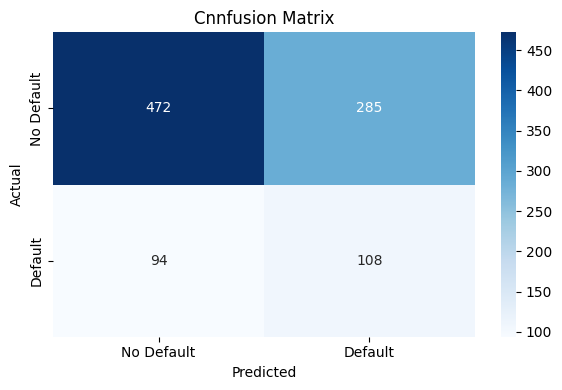

In [20]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Cnnfusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [21]:
# Classification Report
print(classification_report(y_test, y_pred,
                            target_names=['No Default', 'Default']))

              precision    recall  f1-score   support

  No Default       0.83      0.62      0.71       757
     Default       0.27      0.53      0.36       202

    accuracy                           0.60       959
   macro avg       0.55      0.58      0.54       959
weighted avg       0.72      0.60      0.64       959



In [22]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(x_train, y_train)

# Test the model
rf_pred = rf_model.predict(x_test)

# Check accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 79.04 %


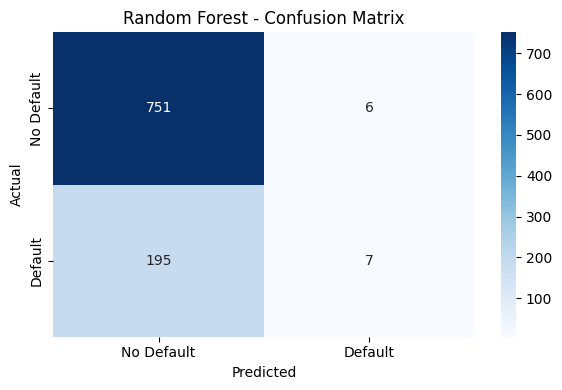

              precision    recall  f1-score   support

  No Default       0.79      0.99      0.88       757
     Default       0.54      0.03      0.07       202

    accuracy                           0.79       959
   macro avg       0.67      0.51      0.47       959
weighted avg       0.74      0.79      0.71       959



In [23]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Classification Report
print(classification_report(y_test, rf_pred,
      target_names=['No Default', 'Default']))

Accuracy: 74.24 %


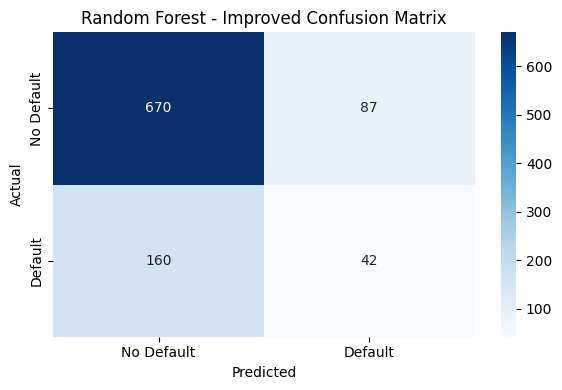

              precision    recall  f1-score   support

  No Default       0.81      0.89      0.84       757
     Default       0.33      0.21      0.25       202

    accuracy                           0.74       959
   macro avg       0.57      0.55      0.55       959
weighted avg       0.71      0.74      0.72       959



In [24]:
from sklearn.ensemble import RandomForestClassifier

# Improved Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight={0: 1, 1: 3},
    max_depth=10,
    random_state=42
)
rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)

print("Accuracy:", round(accuracy_score(y_test, rf_pred) * 100, 2), "%")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Random Forest - Improved Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(classification_report(y_test, rf_pred,
      target_names=['No Default', 'Default']))

In [25]:
import pickle

# save final model
with open(r'D:\Eda_project\loan_default_model.pkl', 'wb') as f:
  pickle.dump(rf_model, f)

print("final model saved successfully")

final model saved successfully


In [26]:
# Export main file for Power BI
df.to_csv(r'D:\Eda_project\loan_powerbi.csv', index=False)
print("File exported successfully!")

File exported successfully!


In [27]:
# Predict for a new customer
new_customer = pd.DataFrame({
    'age': [35],
    'monthly_income': [45000],
    'loan_amount': [2500000],
    'loan_tenure_months': [240],
    'interest_rate': [8.5],
    'credit_score': [620],
    'existing_loans': [2],
    'total_existing_debt': [80000],
    'debt_to_income_ratio': [0.65],
    'employment_type': [1],
    'loan_type': [2],
    'education': [2]
})

prediction = rf_model.predict(new_customer)
probability = rf_model.predict_proba(new_customer)

print("Customer Details:")
print("Age: 35 | Income: ₹45,000 | Credit Score: 620")
print("Loan Amount: ₹25,00,000 | Existing Loans: 2")
print("---")
print("Prediction:", "⚠️ WILL DEFAULT" if prediction[0] == 1 else "✅ WILL NOT DEFAULT")
print("Default Probability:", round(probability[0][1] * 100, 2), "%")

Customer Details:
Age: 35 | Income: ₹45,000 | Credit Score: 620
Loan Amount: ₹25,00,000 | Existing Loans: 2
---
Prediction: ✅ WILL NOT DEFAULT
Default Probability: 42.9 %


In [28]:
new_customer2 = pd.DataFrame({
    'age': [35],
    'monthly_income': [45000],
    'loan_amount': [2500000],
    'loan_tenure_months': [240],
    'interest_rate': [8.5],
    'credit_score': [800],
    'existing_loans': [0],
    'total_existing_debt': [0],
    'debt_to_income_ratio': [0.20],
    'employment_type': [1],
    'loan_type': [2],
    'education': [2]
})

prediction2 = rf_model.predict(new_customer2)
probability2 = rf_model.predict_proba(new_customer2)

print("Prediction:", "⚠️ WILL DEFAULT" if prediction2[0] == 1 else "✅ WILL NOT DEFAULT")
print("Default Probability:", round(probability2[0][1] * 100, 2), "%")

Prediction: ✅ WILL NOT DEFAULT
Default Probability: 12.25 %
